# Práctica 5: Linear Models + Correlation

## Objetivo
Generar un modelo lineal a partir de los datos de tiros de la EPL 2024-2025, analizar la correlación entre variables y obtener el coeficiente de determinación (R²).

## Requisitos
- Calcular la matriz de correlación.
- Generar un modelo de Regresión Lineal Simple.
- Visualizar la recta de regresión.
- Evaluar el modelo con el R² Score.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Configuración de estilo
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Cargar datos
try:
    df = pd.read_csv('cleaned_epl_shots.csv')
    print("Dataset cargado exitosamente.")
except FileNotFoundError:
    print("El archivo no se encuentra. Verifica la ruta.")

df.head()

Dataset cargado exitosamente.


,isHome,shotType,situation,bodyPart,goalMouthLocation,goalMouthCoordinates,blockCoordinates,xg,xgot,id,...,periodTimeSeconds,incidentType,goalType,match_id,match_date,player_name,player_position,player_id,shot_x,shot_y
0,False,block,assisted,left-foot,low-centre,"{""x"": 0, ""y"": 50.1, ""z"": 19}","{""x"": 16.7, ""y"": 39.5, ""z"": 0}",0.044247,0.0,3701430,...,18,shot,NaN,12436910,2024-09-01,Jean-Philippe Mateta,F,848276,19.8,37.6
1,True,block,assisted,right-foot,low-centre,"{""x"": 0, ""y"": 49.5, ""z"": 19}","{""x"": 0.90000000000001, ""y"": 51.6, ""z"": 0}",0.137589,0.0,4475948,...,24,shot,NaN,12436629,2025-02-22,Jaden Philogene-Bidace,M,1014461,7.6,60.1
2,True,block,throw-in-set-piece,left-foot,low-centre,"{""x"": 0, ""y"": 50.7, ""z"": 19}","{""x"": 12.4, ""y"": 50.2, ""z"": 0}",0.052231,0.0,5000250,...,32,shot,NaN,12436538,2025-05-25,Conor Chaplin,M,784625,14.1,50.3
3,False,block,assisted,right-foot,low-centre,"{""x"": 0, ""y"": 51.4, ""z"": 19}","{""x"": 12, ""y"": 69.3, ""z"": 0}",0.047109,0.0,4742872,...,33,shot,NaN,12436614,2025-04-12,Marcus Rashford,M,814590,14.1,72.9
4,True,block,regular,right-foot,low-centre,"{""x"": 0, ""y"": 48.9, ""z"": 19}","{""x"": 13.7, ""y"": 48.7, ""z"": 0}",0.066052,0.0,4202996,...,33,shot,NaN,12436532,2024-12-29,Eberechi Eze,F,864921,15.1,48.5


## 1. Análisis de Correlación
Antes de construir el modelo, analizamos la relación lineal entre las variables numéricas utilizando la correlación de Pearson.

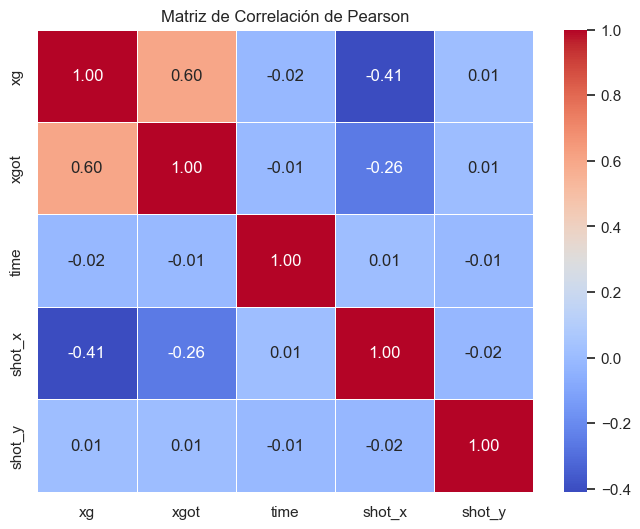

In [2]:
# Seleccionar solo columnas numéricas relevantes para la correlación
numeric_cols = ['xg', 'xgot', 'time', 'shot_x', 'shot_y']
correlation_matrix = df[numeric_cols].corr()

# Visualizar la matriz de correlación
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Pearson')
plt.show()

### Interpretación de la Correlación
- **xG vs xGOT:** Esperamos una correlación positiva fuerte. Cuanto mayor es la probabilidad de gol de la jugada (`xg`), mayor tiende a ser la calidad del tiro resultante (`xgot`), aunque esto depende de la ejecución del jugador.
- **Shot X/Y vs xG:** La ubicación del tiro (`shot_x`, `shot_y`) debería tener alguna correlación con `xg`, ya que la distancia y el ángulo son factores clave en el cálculo de la probabilidad de gol.

## 2. Construcción del Modelo de Regresión Lineal
Vamos a predecir el **xGOT** (calidad de ejecución) basándonos en el **xG** (calidad de la oportunidad).

**Hipótesis:** Existe una relación lineal positiva entre la calidad de la oportunidad y la calidad del tiro final.

*Nota:* Para este ejercicio, filtraremos los tiros que fueron a puerta (donde `xgot` > 0) para evitar el sesgo de los tiros bloqueados o fuera (donde `xgot` es 0 o NaN en algunos proveedores, aunque aquí parece ser 0).

In [3]:
# Filtrar datos: Consideramos solo tiros que generaron xGOT > 0 (tiros a puerta o goles)
# Esto mejora la linealidad, ya que los tiros fuera rompen la relación directa.
df_model = df[df['xgot'] > 0].copy()

# Eliminar filas con valores nulos en xg o xgot para evitar errores en el modelo
df_model = df_model.dropna(subset=['xg', 'xgot'])

# Definir variables
X = df_model[['xg']]  # Variable independiente (Predictor)
y = df_model['xgot']  # Variable dependiente (Target)

# Dividir en conjunto de entrenamiento y prueba (80% - 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inicializar y entrenar el modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Realizar predicciones
y_pred = model.predict(X_test)

print("Modelo entrenado exitosamente.")

Modelo entrenado exitosamente.


## 3. Evaluación del Modelo
Calculamos el coeficiente de determinación ($R^2$) y el Error Cuadrático Medio (MSE).

In [4]:
# Coeficientes del modelo
print(f"Intercepto (b0): {model.intercept_:.4f}")
print(f"Pendiente (b1): {model.coef_[0]:.4f}")

# Métricas de evaluación
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"\nR² Score: {r2:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")

Intercepto (b0): 0.1624
Pendiente (b1): 0.9631

R² Score: 0.4533
Mean Squared Error (MSE): 0.0436


### Interpretación del R²
- Un **R² cercano a 1** indica que el modelo explica gran parte de la variabilidad de los datos.
- Un **R² bajo** sugiere que la relación no es perfectamente lineal o que hay otros factores (como la habilidad individual del jugador o la suerte) que influyen mucho en el `xgot` final.

## 4. Visualización de la Regresión
Graficamos los datos reales junto con la línea de regresión predicha por el modelo.

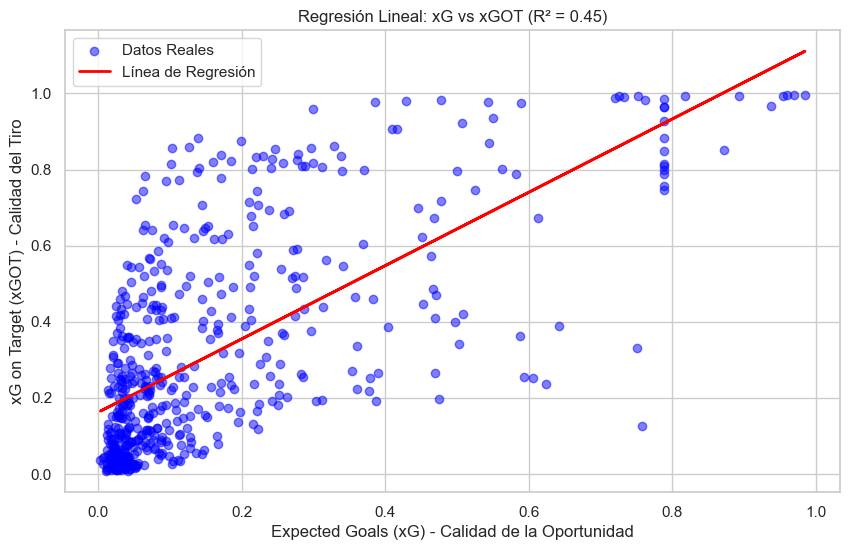

In [5]:
plt.figure(figsize=(10, 6))

# Puntos de datos reales (Test set)
plt.scatter(X_test, y_test, color='blue', alpha=0.5, label='Datos Reales')

# Línea de regresión
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Línea de Regresión')

plt.title(f'Regresión Lineal: xG vs xGOT (R² = {r2:.2f})')
plt.xlabel('Expected Goals (xG) - Calidad de la Oportunidad')
plt.ylabel('xG on Target (xGOT) - Calidad del Tiro')
plt.legend()
plt.show()

## Conclusiones
- Hemos creado un modelo lineal simple para predecir la calidad de ejecución (`xgot`) basada en la calidad de la oportunidad (`xg`).
- El gráfico de dispersión muestra la relación positiva, confirmando que mejores oportunidades suelen resultar en tiros más peligrosos.
- El valor de R² nos indica qué porcentaje de la varianza en la calidad del tiro es explicada solo por la calidad de la oportunidad inicial.